In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)


In [18]:
df_original = pd.read_excel("Telco_customer_churn.xlsx")
df = df_original.copy()
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [19]:
df.shape


(7043, 33)

In [20]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [21]:
df.isnull().sum()


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


In [23]:
if 'Churn Reason' in df.columns:
    df['Churn Reason'] = df['Churn Reason'].fillna('No Churn')


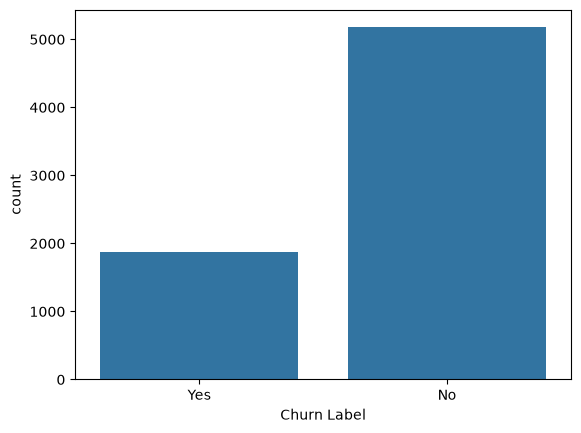

In [24]:
sns.countplot(x='Churn Label', data=df_original)
plt.show()


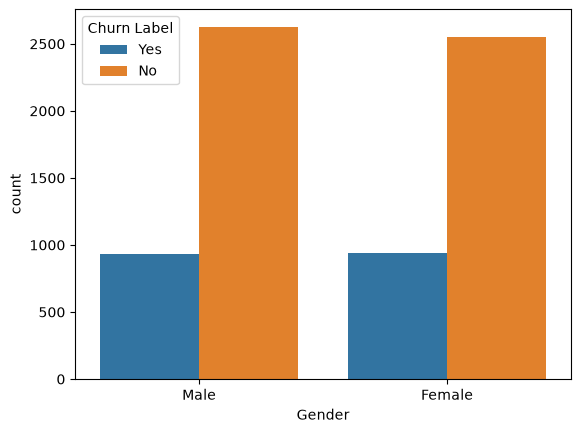

In [25]:
sns.countplot(x='Gender', hue='Churn Label', data=df_original)
plt.show()


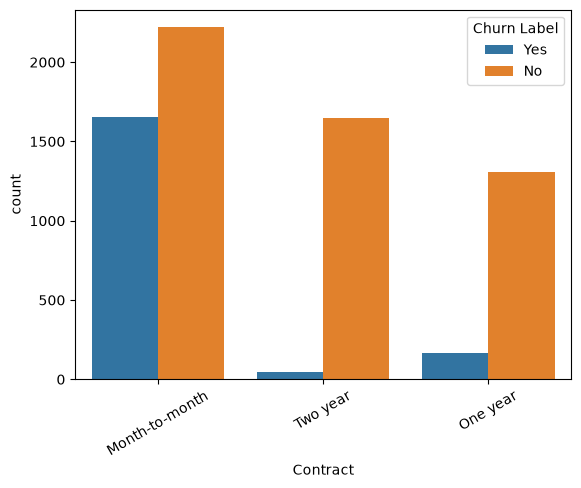

In [26]:
sns.countplot(x='Contract', hue='Churn Label', data=df_original)
plt.xticks(rotation=30)
plt.show()


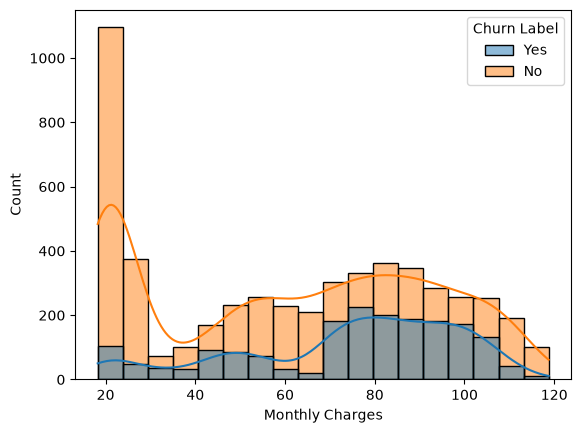

In [27]:
sns.histplot(data=df_original, x='Monthly Charges', hue='Churn Label', kde=True)
plt.show()


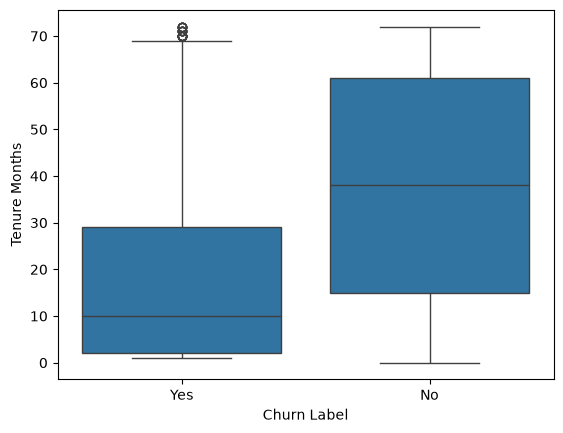

In [28]:
sns.boxplot(x='Churn Label', y='Tenure Months', data=df_original)
plt.show()


In [34]:
drop_columns = [
'CustomerID','Count','Country','State','Zip Code',
'Lat Long','Latitude','Longitude',
'Churn Score','Churn Reason','CLTV'
]

existing = [c for c in drop_columns if c in df.columns]
df = df.drop(columns=existing)


In [35]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

df.head()


,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1


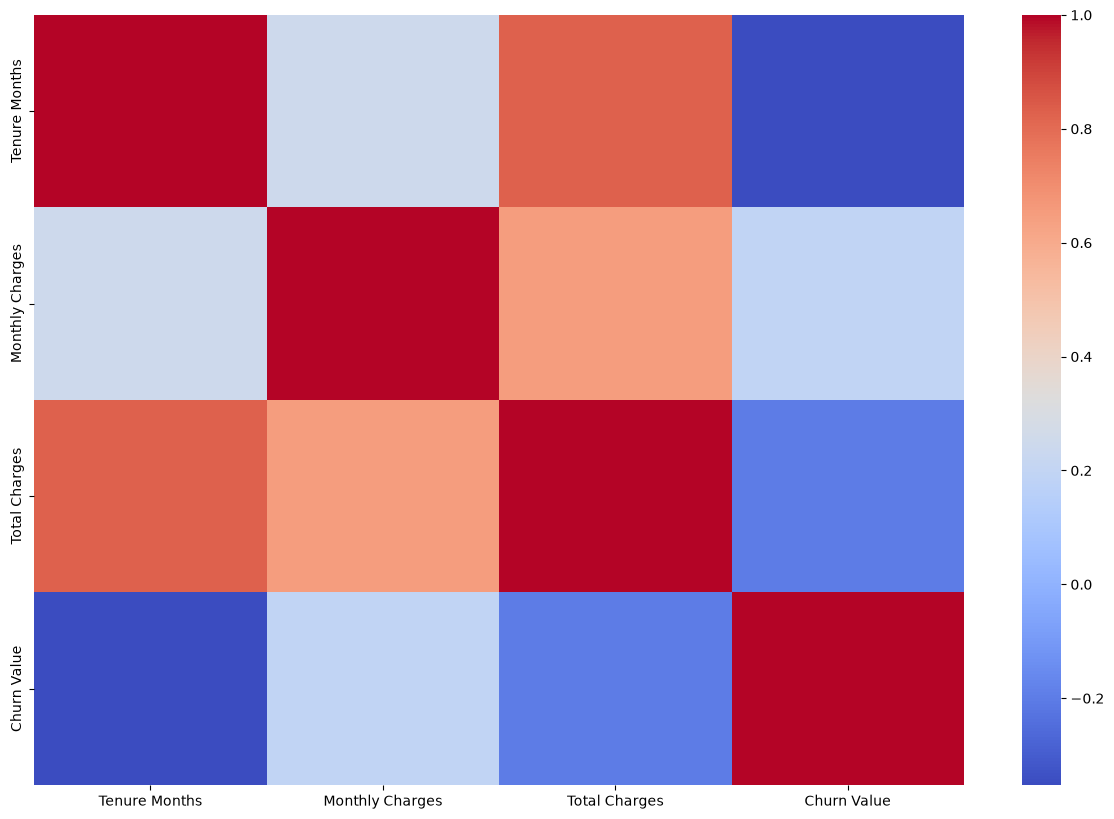

In [37]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)
plt.show()

In [45]:
seg_data = seg_data.replace([np.inf, -np.inf], np.nan)
seg_data = seg_data.fillna(seg_data.median(numeric_only=True))


In [46]:
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_data)

NaN values in scaled data: 0
Infinite values in scaled data: 0


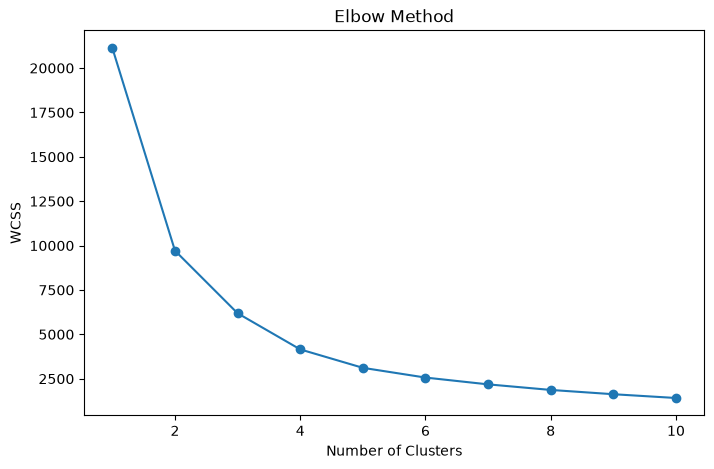

In [47]:
print("NaN values in scaled data:", np.isnan(seg_scaled).sum())
print("Infinite values in scaled data:", np.isinf(seg_scaled).sum())

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(seg_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [48]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Customer Segment'] = kmeans.fit_predict(seg_scaled)


In [49]:
df.groupby('Customer Segment')[seg_features].mean()


,Tenure Months,Monthly Charges,Total Charges
Customer Segment,,,
0,15.424868,80.779657,1252.816564
1,59.530987,93.306224,5548.653887
2,53.585850,34.920147,1836.581320
3,10.228873,31.769131,303.821875


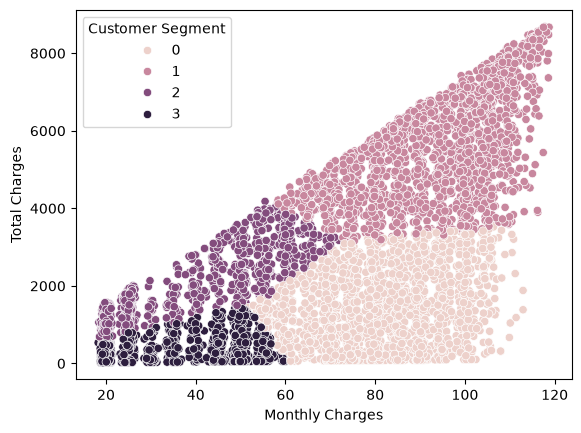

In [50]:
sns.scatterplot(
    x='Monthly Charges',
    y='Total Charges',
    hue='Customer Segment',
    data=df
)
plt.show()


In [51]:
X = df.drop(['Churn Value','Churn Label'], axis=1, errors='ignore')
y = df['Churn Value']


In [52]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)


In [53]:
param_grid = {
'n_estimators':[100,200,300],
'max_depth':[5,10,15],
'min_samples_split':[2,5,10],
'min_samples_leaf':[1,2,4]
}


In [54]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

grid = GridSearchCV(
    pipeline,
    {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [5, 10, 15],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)


In [61]:
grid.best_params_


{'classifier__max_depth': 15,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 100}

In [62]:
rf_tuned = grid.best_estimator_


In [63]:
y_pred = rf_tuned.predict(X_test)


In [64]:
accuracy_score(y_test,y_pred)


0.7601135557132718

In [65]:
precision_score(y_test,y_pred)


0.533457249070632

In [66]:
recall_score(y_test,y_pred)


0.767379679144385

In [67]:
f1_score(y_test,y_pred)


0.6293859649122807

In [68]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



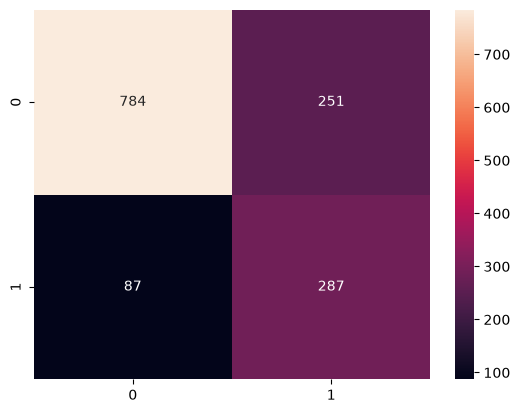

In [69]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.show()


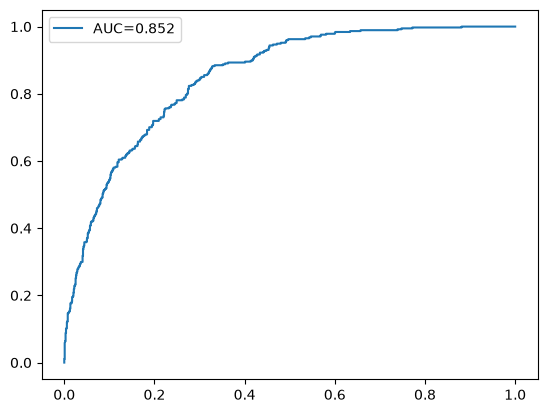

In [70]:
y_prob_test = rf_tuned.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(y_test,y_prob_test)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label=f'AUC={roc_auc:.3f}')
plt.legend()
plt.show()


In [77]:
classifier = rf_tuned.named_steps['classifier']

preprocessor = rf_tuned.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': classifier.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

                                   Feature  Importance
1162          cat__Contract_Month-to-month    0.077236
1171              remainder__Tenure Months    0.071517
1173              remainder__Total Charges    0.062735
1164                cat__Contract_Two year    0.051526
1172            remainder__Monthly Charges    0.048672
1174           remainder__Customer Segment    0.041000
1134                    cat__Dependents_No    0.038332
1135                   cat__Dependents_Yes    0.038123
1144               cat__Online Security_No    0.037499
1153                  cat__Tech Support_No    0.031188
1163                cat__Contract_One year    0.023910
1169  cat__Payment Method_Electronic check    0.023182
1142     cat__Internet Service_Fiber optic    0.023119
1141             cat__Internet Service_DSL    0.021375
1147                 cat__Online Backup_No    0.018027
1146              cat__Online Security_Yes    0.017716
1155                 cat__Tech Support_Yes    0.015827
1165      

In [78]:
df['Churn Probability'] = rf_tuned.predict_proba(X)[:,1]


In [80]:
conditions = [
df['Churn Probability'] >= 0.70,
(df['Churn Probability'] >= 0.40) & (df['Churn Probability'] < 0.70),
df['Churn Probability'] < 0.40
]

choices = ['High Risk','Medium Risk','Low Risk']

df['Risk Category'] = np.select(
conditions,
choices,
default='Low Risk'
)


In [81]:
df[['Churn Probability','Risk Category']].head()


,Churn Probability,Risk Category
0,0.638791,Medium Risk
1,0.799416,High Risk
2,0.810172,High Risk
3,0.609741,Medium Risk
4,0.655550,Medium Risk


In [82]:
high_risk = df[df['Risk Category']=='High Risk']
high_risk.head(20)


,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Customer Segment,Churn Probability,Risk Category
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0,0.799416,High Risk
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,0,0.810172,High Risk
6,Los Angeles,Male,Yes,No,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,3,0.852224,High Risk
9,Los Angeles,Male,No,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,No,Electronic check,30.20,30.20,Yes,1,3,0.717489,High Risk
11,Los Angeles,Male,No,No,Yes,5,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,69.70,316.90,Yes,1,0,0.719880,High Risk
13,Los Angeles,Female,No,No,Yes,11,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Bank transfer (automatic),97.85,1105.40,Yes,1,0,0.791040,High Risk
14,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,80.65,144.15,Yes,1,0,0.801363,High Risk
17,Los Angeles,Male,Yes,No,Yes,18,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes,1,0,0.798262,High Risk
19,Huntington Park,Female,No,No,Yes,1,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,79.35,79.35,Yes,1,0,0.794632,High Risk
20,Lynwood,Female,No,Yes,Yes,7,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Bank transfer (automatic),75.15,496.90,Yes,1,0,0.703076,High Risk


In [ ]:
df.to_csv('customer_churn_results.csv',index=False)